# Business Analytics Project
## Online Retail Sales Analysis

### Group Members
#### Saad Ishfaq
#### M.Saad Bin Asim
#### M.Hamza Tarrar
#### Salman Qasim
#### Rai Abdul Wassey
#### Taha Tahir

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Initialization

In [4]:
df = pd.read_csv(r"C:\Users\hp\Downloads\online_retail_II.csv", encoding='latin1')

print("Dataset loaded successfully!")

df

Dataset loaded successfully!


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,12/4/2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,12/4/2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,12/4/2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,12/4/2011 13:15,2.89,16931.0,United Kingdom


## Data Profiling

In [4]:
df.shape

(1048575, 8)

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom


In [6]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,12/4/2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,12/4/2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,12/4/2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,12/4/2011 13:15,2.89,16931.0,United Kingdom
1048574,580502,23046,PAPER LANTERN 9 POINT DELUXE STAR,1,12/4/2011 13:15,6.65,16931.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [8]:
df.describe()

,Quantity,Price,Customer ID
count,1.048575e+06,1.048575e+06,811893.000000
mean,9.957525e+00,4.627346e+00,15324.712265
std,1.335187e+02,1.228024e+02,1697.033034
min,-7.421500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13971.000000
50%,3.000000e+00,2.100000e+00,15260.000000
75%,1.000000e+01,4.150000e+00,16795.000000
max,7.421500e+04,3.897000e+04,18287.000000


In [9]:
print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

Column Names:
  - Invoice
  - StockCode
  - Description
  - Quantity
  - InvoiceDate
  - Price
  - Customer ID
  - Country


In [10]:
print("Unique Values")
print("Country (top 10):", df['Country'].value_counts().head(10).index.tolist())
print("Total Unique Countries:", df['Country'].nunique())
print("Total Unique Customers:", df['Customer ID'].nunique())
print("Total Unique Products:", df['StockCode'].nunique())

Unique Values
Country (top 10): ['United Kingdom', 'EIRE', 'Germany', 'France', 'Netherlands', 'Spain', 'Switzerland', 'Belgium', 'Portugal', 'Australia']
Total Unique Countries: 43
Total Unique Customers: 5924
Total Unique Products: 5304


# Data Cleaning

In [6]:
# Check missing values in each column
df.isna().sum()

Invoice             0
StockCode           0
Description      4372
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236682
Country             0
dtype: int64

In [7]:
# Check missing values percentage
(df.isna().sum() / len(df)) * 100

Invoice         0.000000
StockCode       0.000000
Description     0.416947
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    22.571776
Country         0.000000
dtype: float64

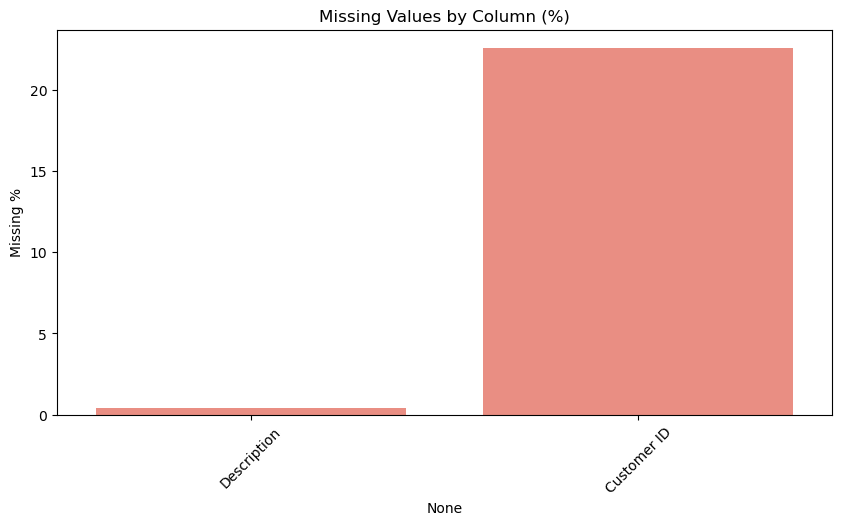

In [8]:
# Visualize missing values
missing_pct = df.isna().sum() / len(df) * 100
missing_pct = missing_pct[missing_pct > 0]

plt.subplots(figsize=(10, 5))
sns.barplot(x=missing_pct.index, y=missing_pct.values, color='salmon')
plt.title('Missing Values by Column (%)')
plt.xticks(rotation=45)
plt.ylabel('Missing %')
plt.show()

In [9]:
# Drop rows where Customer ID is missing (cannot analyze customer behaviour without it)
df = df.dropna(subset=['Customer ID'])

# Fill missing Description with 'Unknown'
df['Description'] = df['Description'].fillna('Unknown')

df

C:\Users\hp\AppData\Local\Temp\ipykernel_11708\1917409871.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Description'] = df['Description'].fillna('Unknown')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,12/4/2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,12/4/2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,12/4/2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,12/4/2011 13:15,2.89,16931.0,United Kingdom


In [10]:
# Verify - check missing values after cleaning
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

## Detect and Remove Duplicates

In [11]:
df.duplicated().sum()

np.int64(26294)

In [12]:
# Remove duplicate rows
df = df.drop_duplicates()
df.shape

(785599, 8)

## Remove Irrelevant Variables and Invalid Records

In [13]:
# Drop StockCode and Description - not useful for numerical analysis
df = df.drop(columns=['StockCode', 'Description'])

df

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,12/1/2009 7:45,6.95,13085.0,United Kingdom
1,489434,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
2,489434,12,12/1/2009 7:45,6.75,13085.0,United Kingdom
3,489434,48,12/1/2009 7:45,2.10,13085.0,United Kingdom
4,489434,24,12/1/2009 7:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...
1048570,580501,2,12/4/2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,3,12/4/2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,3,12/4/2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,2,12/4/2011 13:15,2.89,16931.0,United Kingdom


In [14]:
# Remove cancelled orders (Invoice starting with 'C') and negative quantities/prices
print("Cancelled orders:", df['Invoice'].astype(str).str.startswith('C').sum())
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero Quantity and Price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

print("Shape after removing invalid records:", df.shape)

Cancelled orders: 18160
Shape after removing invalid records: (767369, 6)


## Detect and Handle Outliers

In [15]:
print("Quantity distribution:")
print(df['Quantity'].describe())
print(f"\nRows with Quantity > 1000: {(df['Quantity'] > 1000).sum()}")

Quantity distribution:
count    767369.000000
mean         13.399990
std         114.173661
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       74215.000000
Name: Quantity, dtype: float64

Rows with Quantity > 1000: 290


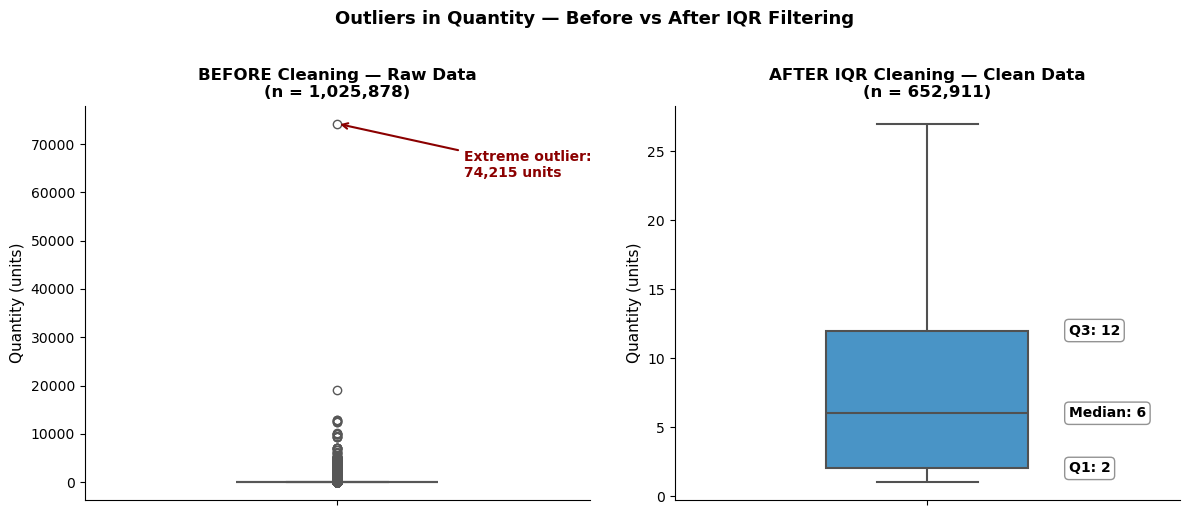


=== QUANTITY: BEFORE vs AFTER COMPARISON ===
Metric                        BEFORE           AFTER
--------------------------------------------------
Records                    1,025,878         652,911
Max Quantity                  74,215              27
Median                             3               6
Q3 (75th %ile)                    11              12

Records removed: 372,967 (36.36%)


In [76]:
# Boxplot — Quantity Outliers (TRUE Before vs After)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Reload raw data just for the "before" view ──────────────
df_raw = pd.read_csv(r"C:\Users\hp\Downloads\online_retail_II.csv", encoding='latin1')
df_raw = df_raw[df_raw['Quantity'] > 0]   # only positive values for fair comparison

# ── Panel 1: BEFORE — raw data with extreme outliers ────────
sns.boxplot(y='Quantity', data=df_raw, ax=axes[0], color='#e74c3c',
            width=0.4, linewidth=1.5)
axes[0].set_title(f'BEFORE Cleaning — Raw Data\n(n = {len(df_raw):,})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantity (units)', fontsize=11)
axes[0].set_xlabel('')
sns.despine(ax=axes[0])

max_qty_raw = df_raw['Quantity'].max()
axes[0].annotate(f'Extreme outlier:\n{max_qty_raw:,} units',
                 xy=(0, max_qty_raw), xytext=(0.25, max_qty_raw * 0.85),
                 fontsize=10, fontweight='bold', color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

# ── Panel 2: AFTER — your cleaned data ──────────────────────
sns.boxplot(y='quantity', data=df, ax=axes[1], color='#3498db',
            width=0.4, linewidth=1.5)
axes[1].set_title(f'AFTER IQR Cleaning — Clean Data\n(n = {len(df):,})',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Quantity (units)', fontsize=11)
axes[1].set_xlabel('')
sns.despine(ax=axes[1])

# Annotate Q1, Median, Q3 on the after panel
q1 = df['quantity'].quantile(0.25)
med = df['quantity'].median()
q3 = df['quantity'].quantile(0.75)
for val, label in [(q1, 'Q1'), (med, 'Median'), (q3, 'Q3')]:
    axes[1].text(0.28, val, f'{label}: {val:.0f}',
                 va='center', fontsize=10, fontweight='bold', color='black',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='gray', alpha=0.85))

plt.suptitle('Outliers in Quantity — Before vs After IQR Filtering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print comparison summary
print(f"\n=== QUANTITY: BEFORE vs AFTER COMPARISON ===")
print(f"{'Metric':<20} {'BEFORE':>15} {'AFTER':>15}")
print(f"{'-'*50}")
print(f"{'Records':<20} {len(df_raw):>15,} {len(df):>15,}")
print(f"{'Max Quantity':<20} {df_raw['Quantity'].max():>15,} {df['quantity'].max():>15,}")
print(f"{'Median':<20} {df_raw['Quantity'].median():>15.0f} {df['quantity'].median():>15.0f}")
print(f"{'Q3 (75th %ile)':<20} {df_raw['Quantity'].quantile(0.75):>15.0f} {df['quantity'].quantile(0.75):>15.0f}")
print(f"\nRecords removed: {len(df_raw) - len(df):,} ({(1 - len(df)/len(df_raw))*100:.2f}%)")

# Cleanup — delete df_raw to free memory
del df_raw

In [17]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

2.0 12.0 10.0


In [18]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound, upper_bound)

-13.0 27.0


In [19]:
# Remove Quantity outliers using IQR
df = df[(df['Quantity'] >= lower_bound) & (df['Quantity'] <= upper_bound)]
print(df.shape)

df['Quantity'].describe()

(717056, 6)


count    717056.000000
mean          6.973540
std           6.602027
min           1.000000
25%           2.000000
50%           4.000000
75%          12.000000
max          27.000000
Name: Quantity, dtype: float64

<module 'matplotlib.pyplot' from 'C:\\Users\\hp\\anaconda3\\Lib\\site-packages\\matplotlib\\pyplot.py'>

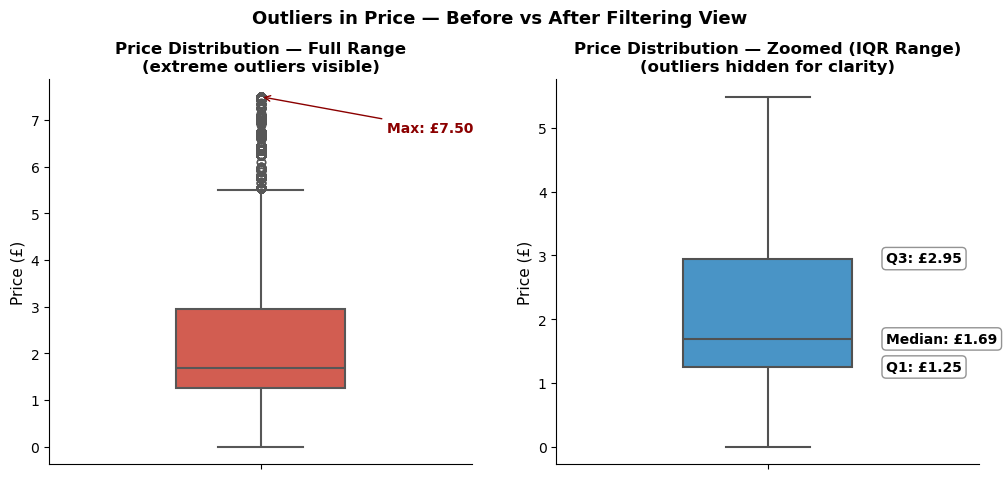

In [71]:
# Boxplot — Price Outliers (IMPROVED)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel 1: Full view — exposes the extreme outliers ──────
sns.boxplot(y='price', data=df, ax=axes[0], color='#e74c3c',
            width=0.4, linewidth=1.5)
axes[0].set_title('Price Distribution — Full Range\n(extreme outliers visible)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (£)', fontsize=11)
axes[0].set_xlabel('')
sns.despine(ax=axes[0])

# Annotate the extreme value
max_price = df['price'].max()
axes[0].annotate(f'Max: £{max_price:,.2f}',
                 xy=(0, max_price), xytext=(0.3, max_price * 0.9),
                 fontsize=10, fontweight='bold', color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))

# ── Panel 2: Zoomed view — actual distribution ─────────────
sns.boxplot(y='price', data=df, ax=axes[1], color='#3498db',
            width=0.4, linewidth=1.5, showfliers=False)
axes[1].set_title('Price Distribution — Zoomed (IQR Range)\n(outliers hidden for clarity)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (£)', fontsize=11)
axes[1].set_xlabel('')
sns.despine(ax=axes[1])

# Annotate Q1, Median, Q3 on the zoomed panel
q1 = df['price'].quantile(0.25)
med = df['price'].median()
q3 = df['price'].quantile(0.75)
for val, label in [(q1, 'Q1'), (med, 'Median'), (q3, 'Q3')]:
    axes[1].text(0.28, val, f'{label}: £{val:.2f}',
                 va='center', fontsize=10, fontweight='bold', color='black',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='gray', alpha=0.85))

plt.suptitle('Outliers in Price — Before vs After Filtering View',
             fontsize=13, fontweight='bold', y=1.02)
plt


In [21]:
Q1_p = df['Price'].quantile(0.25)
Q3_p = df['Price'].quantile(0.75)
IQR_p = Q3_p - Q1_p
lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p
print(f"Lower: {lower_p}, Upper: {upper_p}")

df = df[(df['Price'] >= lower_p) & (df['Price'] <= upper_p)]
print(df.shape)

Lower: -2.5, Upper: 7.5
(652911, 6)


# Data Wrangling

## Rename Columns for Cleaner Format

In [22]:
# Rename columns - replace spaces with underscores and lowercase
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.columns

Index(['invoice', 'quantity', 'invoicedate', 'price', 'customer_id',
       'country'],
      dtype='object')

## Convert Date Column and Extract Features

In [23]:
# Convert InvoiceDate to datetime
df['invoicedate'] = pd.to_datetime(df['invoicedate'])
df['month'] = df['invoicedate'].dt.month
df['month_name'] = df['invoicedate'].dt.strftime('%B')
df['quarter'] = df['invoicedate'].dt.quarter
df['day_of_week'] = df['invoicedate'].dt.day_name()
df['year'] = df['invoicedate'].dt.year
df['hour'] = df['invoicedate'].dt.hour

df[['invoicedate', 'month', 'month_name', 'quarter', 'day_of_week', 'year', 'hour']].head()

,invoicedate,month,month_name,quarter,day_of_week,year,hour
0,2009-12-01 07:45:00,12,December,4,Tuesday,2009,7
1,2009-12-01 07:45:00,12,December,4,Tuesday,2009,7
2,2009-12-01 07:45:00,12,December,4,Tuesday,2009,7
4,2009-12-01 07:45:00,12,December,4,Tuesday,2009,7
5,2009-12-01 07:45:00,12,December,4,Tuesday,2009,7


## Add New Derived Columns

In [24]:
# Total Revenue per transaction
df = df.copy()
df['total_revenue'] = (df['quantity'] * df['price']).round(2)

df['total_revenue'].describe()

count    652911.000000
mean         13.030374
std          13.347765
min           0.000000
25%           4.160000
50%          10.200000
75%          17.400000
max         182.250000
Name: total_revenue, dtype: float64

In [25]:
# Revenue Segment based on Total Revenue
df['revenue_segment'] = pd.cut(df['total_revenue'],
                                bins=[0, 10, 50, 200, float('inf')],
                                labels=['Low', 'Medium', 'High', 'Premium'])
df['revenue_segment'].value_counts()

revenue_segment
Medium     324491
Low        313622
High        14780
Premium         0
Name: count, dtype: int64

In [26]:
# Price Tier
df['price_tier'] = pd.cut(df['price'],
                           bins=[0, 2, 5, 15, float('inf')],
                           labels=['Budget', 'Mid', 'Premium', 'Luxury'])
df['price_tier'].value_counts()

price_tier
Budget     363643
Mid        247747
Premium     41521
Luxury          0
Name: count, dtype: int64

In [27]:
# High Value Transaction Flag
df['high_value'] = (df['total_revenue'] > df['total_revenue'].median()).astype(int)
df['high_value'].value_counts()

high_value
0    338814
1    314097
Name: count, dtype: int64

In [28]:
# Customer Purchase Count (frequency)
purchase_counts = df.groupby('customer_id')['invoice'].nunique().reset_index()
purchase_counts.columns = ['customer_id', 'purchase_count']
df = df.merge(purchase_counts, on='customer_id', how='left')
df['purchase_count'].describe()

count    652911.000000
mean         29.476186
std          59.805297
min           1.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         360.000000
Name: purchase_count, dtype: float64

In [29]:
# Customer Segment based on purchase frequency
df['customer_segment'] = pd.cut(df['purchase_count'],
                                 bins=[0, 2, 5, 15, float('inf')],
                                 labels=['One-Time', 'Occasional', 'Regular', 'Loyal'])
df['customer_segment'].value_counts()

customer_segment
Loyal         243601
Regular       233383
Occasional    108193
One-Time       67734
Name: count, dtype: int64

In [30]:
for col in df.columns:
    print(f"  - {col}")

  - invoice
  - quantity
  - invoicedate
  - price
  - customer_id
  - country
  - month
  - month_name
  - quarter
  - day_of_week
  - year
  - hour
  - total_revenue
  - revenue_segment
  - price_tier
  - high_value
  - purchase_count
  - customer_segment


In [31]:
df.head()

,invoice,quantity,invoicedate,price,customer_id,country,month,month_name,quarter,day_of_week,year,hour,total_revenue,revenue_segment,price_tier,high_value,purchase_count,customer_segment
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,83.4,High,Premium,1,8,Regular
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,81.0,High,Premium,1,8,Regular
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,81.0,High,Premium,1,8,Regular
3,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,30.0,Medium,Budget,1,8,Regular
4,489434,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,39.6,Medium,Budget,1,8,Regular


## Encode Categorical Variables

In [32]:
# Dummy variables for Country (top 5 only to avoid too many columns)
top_countries = df['country'].value_counts().head(5).index
df['country_top'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
d_country = pd.get_dummies(df['country_top']).astype(int)
d_country

,EIRE,France,Germany,Other,Spain,United Kingdom
0,0,0,0,0,0,1
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1
...,...,...,...,...,...,...
652906,0,0,0,0,0,1
652907,0,0,0,0,0,1
652908,0,0,0,0,0,1
652909,0,0,0,0,0,1


In [33]:
# Dummy variables for Day of Week
d_day = pd.get_dummies(df['day_of_week']).astype(int)
d_day

,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...
652906,0,0,0,1,0,0,0
652907,0,0,0,1,0,0,0
652908,0,0,0,1,0,0,0
652909,0,0,0,1,0,0,0


In [34]:
# Combine with original dataframe
df_with_dummy = df.join([d_country, d_day])
df_with_dummy.head()

,invoice,quantity,invoicedate,price,customer_id,country,month,month_name,quarter,day_of_week,...,Other,Spain,United Kingdom,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,December,4,Tuesday,...,0,0,1,0,0,0,0,0,1,0
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,...,0,0,1,0,0,0,0,0,1,0
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,...,0,0,1,0,0,0,0,0,1,0
3,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,December,4,Tuesday,...,0,0,1,0,0,0,0,0,1,0
4,489434,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,12,December,4,Tuesday,...,0,0,1,0,0,0,0,0,1,0


In [35]:
# Final Dataset Shape
df.shape

(652911, 19)

In [36]:
# Sample of final dataset
df.head()

,invoice,quantity,invoicedate,price,customer_id,country,month,month_name,quarter,day_of_week,year,hour,total_revenue,revenue_segment,price_tier,high_value,purchase_count,customer_segment,country_top
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,83.4,High,Premium,1,8,Regular,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,81.0,High,Premium,1,8,Regular,United Kingdom
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,81.0,High,Premium,1,8,Regular,United Kingdom
3,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,30.0,Medium,Budget,1,8,Regular,United Kingdom
4,489434,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,12,December,4,Tuesday,2009,7,39.6,Medium,Budget,1,8,Regular,United Kingdom


# Exploratory Data Analysis (EDA)

## Target Variable Analysis – Revenue Distribution

In [37]:
df['revenue_segment'].value_counts()

revenue_segment
Medium     324491
Low        313622
High        14780
Premium         0
Name: count, dtype: int64

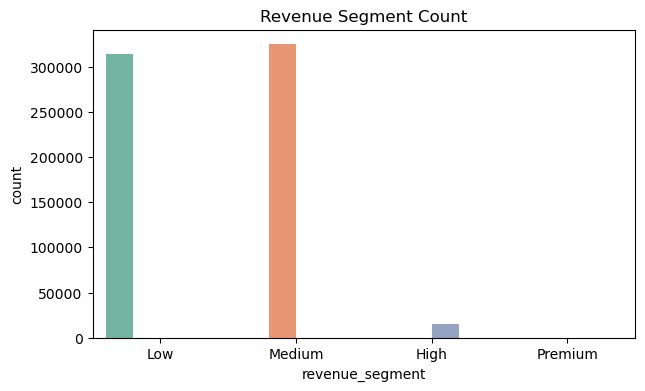

In [38]:
# Bar chart - Revenue Segment Count
plt.subplots(figsize=(7, 4))
sns.countplot(x='revenue_segment', hue='revenue_segment', data=df, palette='Set2', legend=False)
plt.title('Revenue Segment Count')
plt.show()

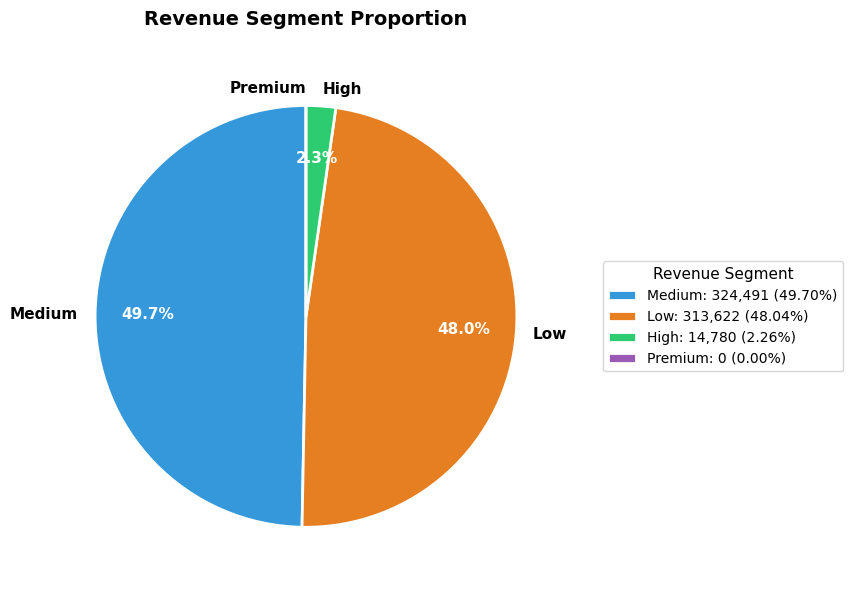

In [69]:
# Pie Chart — Revenue Segment Proportion 
seg_counts = df['revenue_segment'].value_counts()

# Custom colours for each segment
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']  # Medium, Low, High, Premium

plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = plt.pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',   # hide tiny percentages
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    labeldistance=1.08,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Style the percentage text inside the pie
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Build a legend with exact counts and percentages (handles tiny slices clearly)
total = seg_counts.sum()
legend_labels = [
    f'{seg}: {count:,} ({count/total*100:.2f}%)'
    for seg, count in seg_counts.items()
]
plt.legend(wedges, legend_labels, title='Revenue Segment',
           loc='center left', bbox_to_anchor=(1.05, 0.5),
           fontsize=10, title_fontsize=11)

plt.title('Revenue Segment Proportion', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Univariate Analysis – Numerical Features

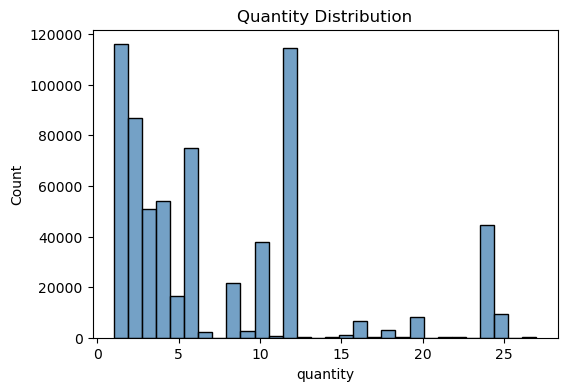

In [40]:
# Distribution - Quantity
plt.subplots(figsize=(6, 4))
sns.histplot(x='quantity', data=df, color='steelblue', bins=30)
plt.title('Quantity Distribution')
plt.show()

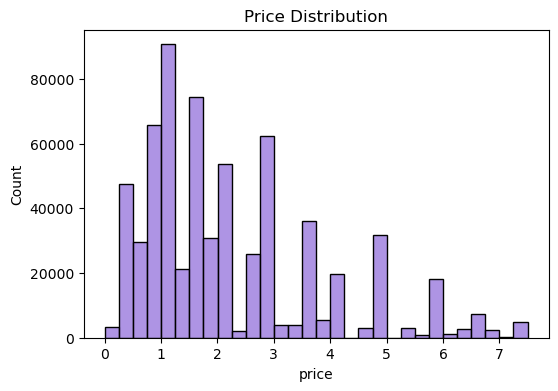

In [41]:
# Distribution - Price
plt.subplots(figsize=(6, 4))
sns.histplot(x='price', data=df, color='mediumpurple', bins=30)
plt.title('Price Distribution')
plt.show()

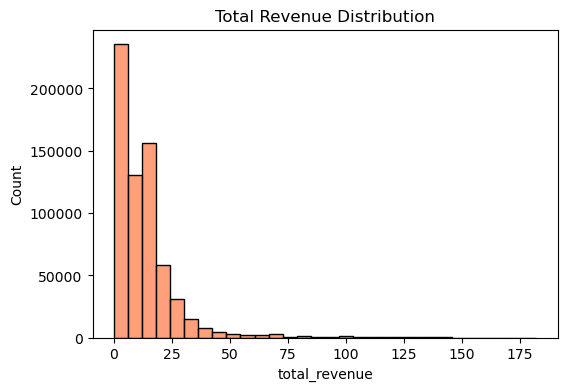

In [42]:
# Distribution - Total Revenue
plt.subplots(figsize=(6, 4))
sns.histplot(x='total_revenue', data=df, color='coral', bins=30)
plt.title('Total Revenue Distribution')
plt.show()

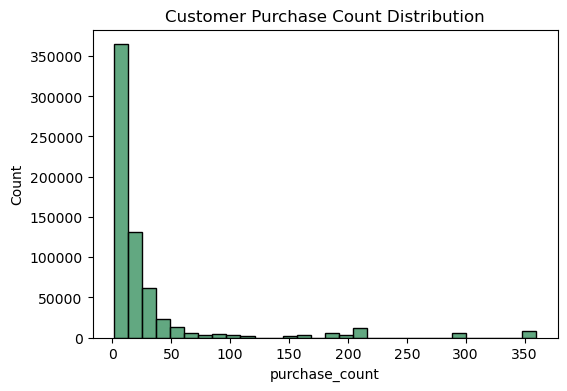

In [43]:
# Distribution - Purchase Count
plt.subplots(figsize=(6, 4))
sns.histplot(x='purchase_count', data=df, color='seagreen', bins=30)
plt.title('Customer Purchase Count Distribution')
plt.show()

## Univariate Analysis – Categorical Features

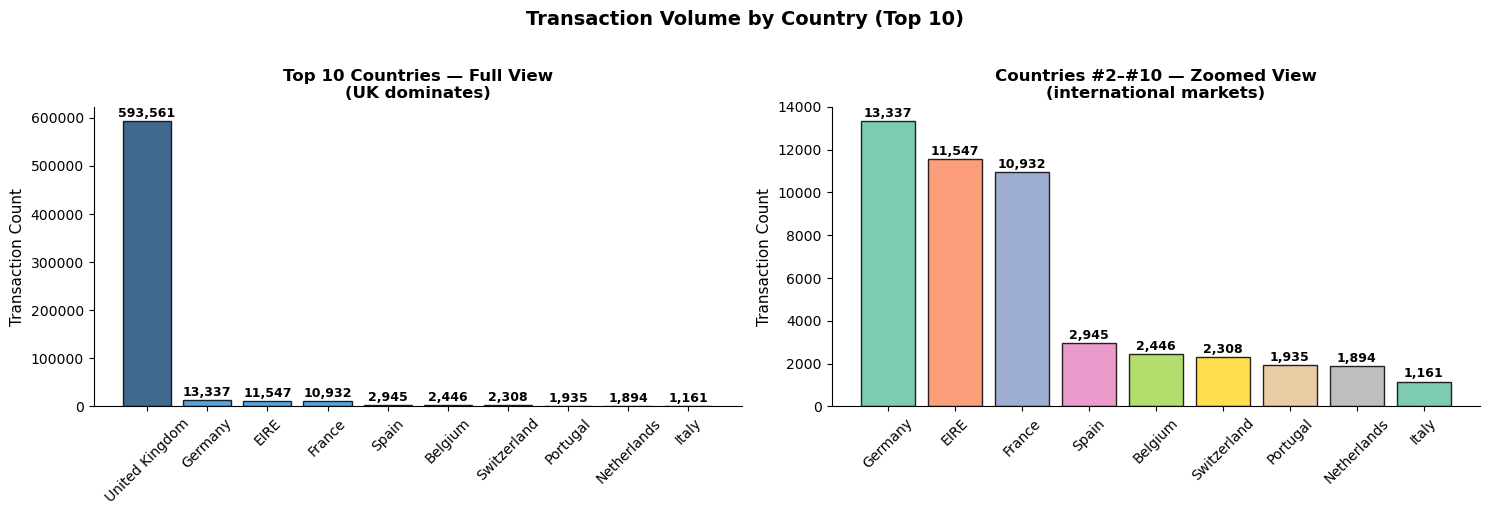


=== TOP 10 COUNTRIES — TRANSACTION DISTRIBUTION ===
  United Kingdom      :  593,561  (90.91%)
  Germany             :   13,337  ( 2.04%)
  EIRE                :   11,547  ( 1.77%)
  France              :   10,932  ( 1.67%)
  Spain               :    2,945  ( 0.45%)
  Belgium             :    2,446  ( 0.37%)
  Switzerland         :    2,308  ( 0.35%)
  Portugal            :    1,935  ( 0.30%)
  Netherlands         :    1,894  ( 0.29%)
  Italy               :    1,161  ( 0.18%)

UK dominance: 90.9% of all transactions


In [73]:
# Top 10 Countries by Transaction Volume — IMPROVED
top_countries_plot = df['country'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Panel 1: All 10 countries — full scale ─────────────────
colors_all = ['#1F4E79' if c == 'United Kingdom' else '#3498db' 
              for c in top_countries_plot.index]

bars1 = axes[0].bar(top_countries_plot.index, top_countries_plot.values,
                    color=colors_all, edgecolor='black', alpha=0.85)

# Annotate each bar with its count
for bar, val in zip(bars1, top_countries_plot.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 8000,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

axes[0].set_title('Top 10 Countries — Full View\n(UK dominates)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[0])

# ── Panel 2: Countries 2-10 — zoomed in ────────────────────
top_excl_uk = top_countries_plot.iloc[1:]   # remove UK

bars2 = axes[1].bar(top_excl_uk.index, top_excl_uk.values,
                    color=sns.color_palette('Set2', n_colors=len(top_excl_uk)),
                    edgecolor='black', alpha=0.85)

for bar, val in zip(bars2, top_excl_uk.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Countries #2–#10 — Zoomed View\n(international markets)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Transaction Count', fontsize=11)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
sns.despine(ax=axes[1])

plt.suptitle('Transaction Volume by Country (Top 10)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print exact distribution for the report
total = df['country'].value_counts().sum()
print(f"\n=== TOP 10 COUNTRIES — TRANSACTION DISTRIBUTION ===")
for country, count in top_countries_plot.items():
    print(f"  {country:<20}: {count:>8,}  ({count/total*100:5.2f}%)")
print(f"\nUK dominance: {top_countries_plot['United Kingdom']/total*100:.1f}% of all transactions")


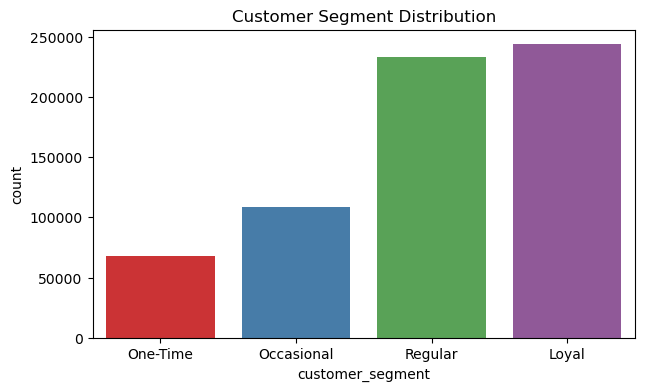

In [45]:
# Customer Segment Distribution
plt.subplots(figsize=(7, 4))
sns.countplot(x='customer_segment', hue='customer_segment', data=df, palette='Set1', legend=False)
plt.title('Customer Segment Distribution')
plt.show()

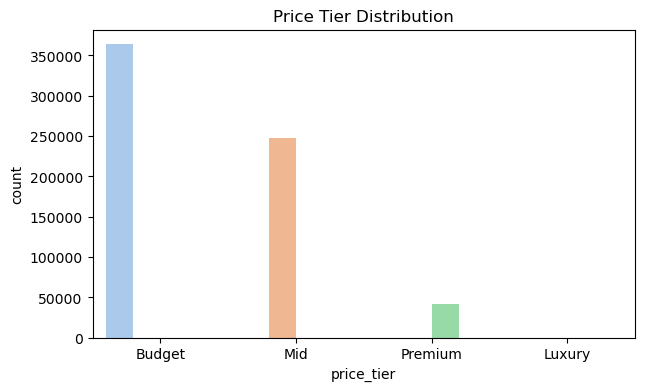

In [46]:
# Price Tier Distribution
plt.subplots(figsize=(7, 4))
sns.countplot(x='price_tier', hue='price_tier', data=df, palette='pastel', legend=False)
plt.title('Price Tier Distribution')
plt.show()

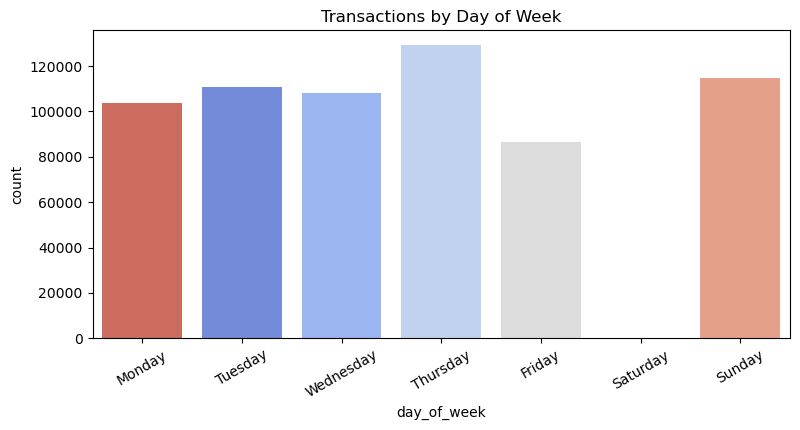

In [47]:
# Day of Week Distribution
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.subplots(figsize=(9, 4))
sns.countplot(x='day_of_week', hue='day_of_week', data=df, order=day_order, palette='coolwarm', legend=False)
plt.title('Transactions by Day of Week')
plt.xticks(rotation=30)
plt.show()

## Bivariate Analysis

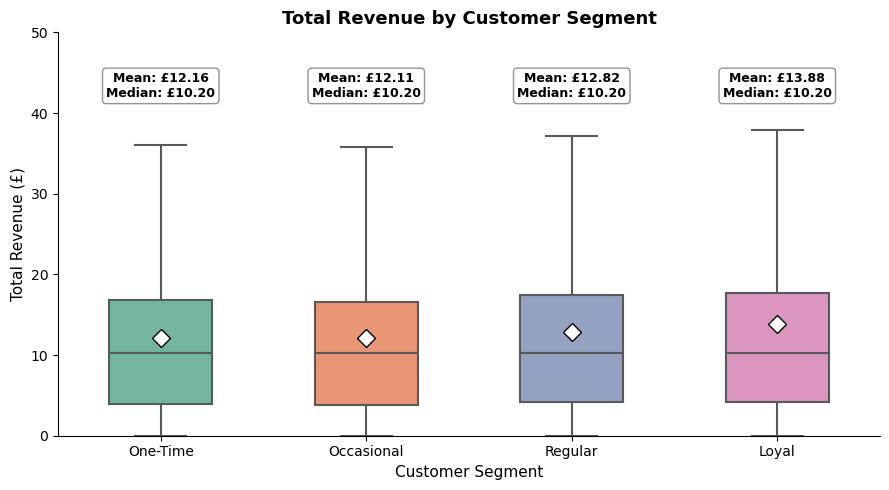

In [68]:
# Total Revenue by Customer Segment — IMPROVED with MEAN annotation
plt.subplots(figsize=(9, 5))

sns.boxplot(
    x='customer_segment',
    y='total_revenue',
    data=df,
    hue='customer_segment',
    palette='Set2',
    legend=False,
    showfliers=False,
    width=0.5,
    linewidth=1.5,
    showmeans=True,                                    # show mean as a marker
    meanprops={'marker':'D', 'markerfacecolor':'white',
               'markeredgecolor':'black', 'markersize':9}
)

# Annotate MEAN (not median) on each box — this shows the real differences
for i, seg in enumerate(df['customer_segment'].cat.categories):
    mean_val = df[df['customer_segment'] == seg]['total_revenue'].mean()
    median_val = df[df['customer_segment'] == seg]['total_revenue'].median()
    plt.text(i, 42,
             f'Mean: £{mean_val:.2f}\nMedian: £{median_val:.2f}',
             ha='center', fontsize=9, fontweight='bold', color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='gray', alpha=0.85))

plt.title('Total Revenue by Customer Segment', fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=11)
plt.ylabel('Total Revenue (£)', fontsize=11)
plt.ylim(0, 50)
sns.despine()
plt.tight_layout()
plt.show()

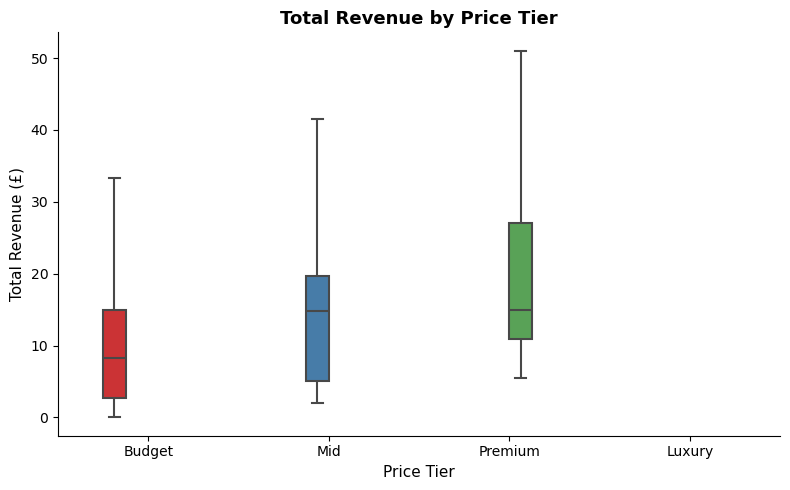

In [66]:
# Total Revenue by Price Tier

plt.subplots(figsize=(8, 5))

sns.boxplot(
    x='price_tier',
    y='total_revenue',
    data=df,
    hue='price_tier',          
    palette='Set1',
    legend=False,
    showfliers=False,          # removes the outlier dots
    width=0.5,
    linewidth=1.5
)

plt.title('Total Revenue by Price Tier', fontsize=13, fontweight='bold')
plt.xlabel('Price Tier', fontsize=11)
plt.ylabel('Total Revenue (£)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

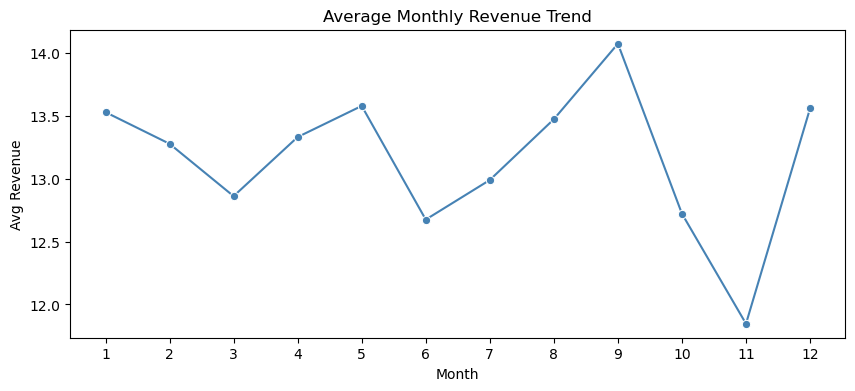

In [50]:
# Average Monthly Revenue Trend
monthly_rev = df.groupby('month')['total_revenue'].mean().reset_index()
plt.subplots(figsize=(10, 4))
sns.lineplot(x='month', y='total_revenue', data=monthly_rev, marker='o', color='steelblue')
plt.title('Average Monthly Revenue Trend')
plt.xticks(range(1, 13))
plt.xlabel('Month')
plt.ylabel('Avg Revenue')
plt.show()

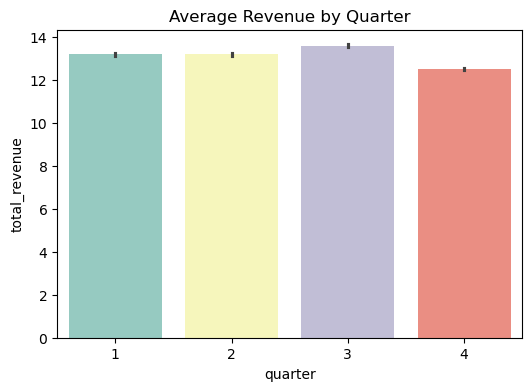

In [51]:
# Revenue by Quarter
plt.subplots(figsize=(6, 4))
sns.barplot(x='quarter', y='total_revenue', hue='quarter', data=df, palette='Set3', legend=False, estimator='mean')
plt.title('Average Revenue by Quarter')
plt.show()


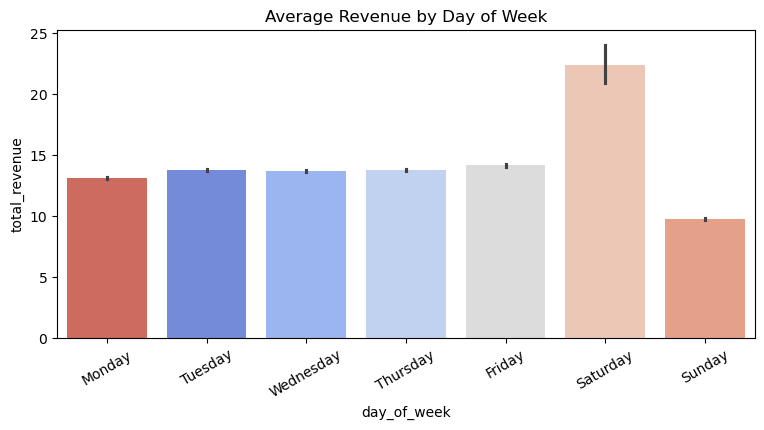

In [52]:
# Revenue by Day of Week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.subplots(figsize=(9, 4))
sns.barplot(x='day_of_week', y='total_revenue', hue='day_of_week', data=df, order=day_order, palette='coolwarm', legend=False, estimator='mean')
plt.title('Average Revenue by Day of Week')
plt.xticks(rotation=30)
plt.show()

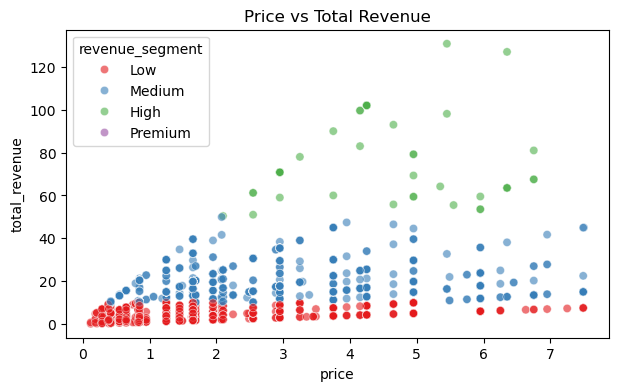

In [53]:
# Scatter - Price vs Total Revenue
sample_df = df.sample(n=2000, random_state=42)
plt.subplots(figsize=(7, 4))
sns.scatterplot(x='price', y='total_revenue', hue='revenue_segment', data=sample_df, palette='Set1', alpha=0.6)
plt.title('Price vs Total Revenue')
plt.show()

## Multivariate Analysis

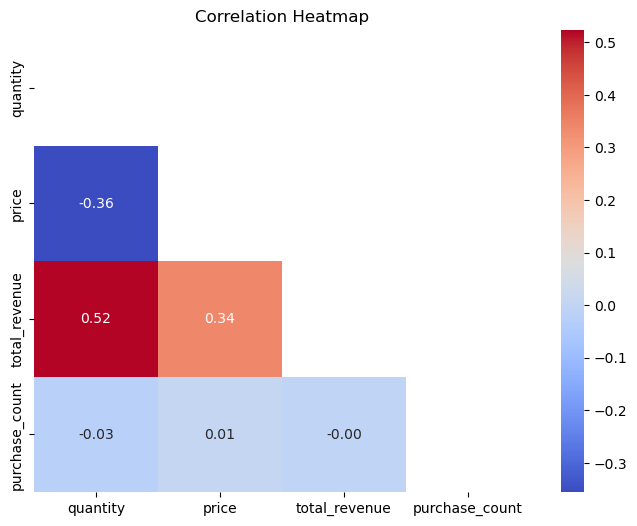

In [54]:
# Heatmap - Numerical Correlations
numeric_cols = ['quantity', 'price', 'total_revenue', 'purchase_count']
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

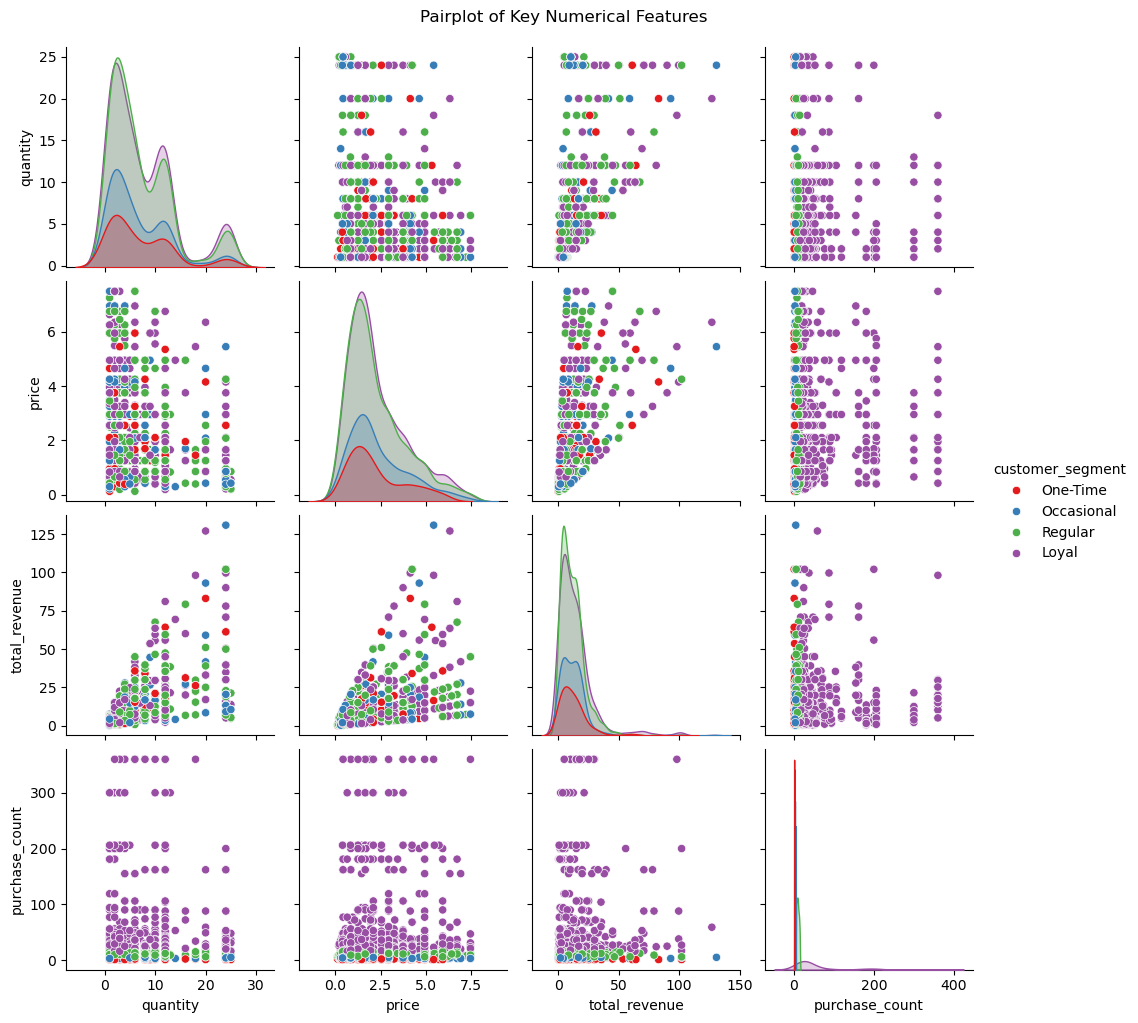

In [55]:
# Pairplot - Key Numerical Features
sample_df = df[['quantity', 'price', 'total_revenue', 'purchase_count', 'customer_segment']].sample(n=2000, random_state=42)
sns.pairplot(sample_df, hue='customer_segment', palette='Set1')
plt.suptitle('Pairplot of Key Numerical Features', y=1.02)
plt.show()

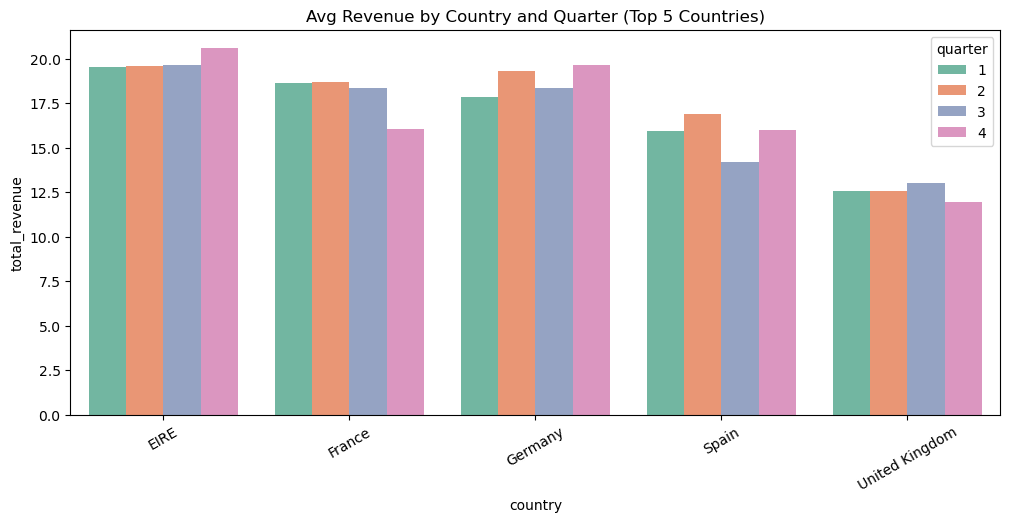

In [56]:
# Grouped Bar - Avg Revenue by Country and Quarter (top 5 countries)
top5 = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top5)]
grouped = df_top5.groupby(['country', 'quarter'])['total_revenue'].mean().reset_index()
plt.subplots(figsize=(12, 5))
sns.barplot(x='country', y='total_revenue', hue='quarter', data=grouped, palette='Set2')
plt.title('Avg Revenue by Country and Quarter (Top 5 Countries)')
plt.xticks(rotation=30)
plt.show()

# Statistical Analysis & Hypothesis Testing

### Descriptive Statistics of Revenue

In [59]:
# ═══════════════════════════════════════════════════════════
# STATISTICAL ANALYSIS & HYPOTHESIS TESTING
# ═══════════════════════════════════════════════════════════
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("DESCRIPTIVE STATISTICS — Total Revenue")
print("=" * 60)
print(df['total_revenue'].describe().round(2))

DESCRIPTIVE STATISTICS — Total Revenue
count    652911.00
mean         13.03
std          13.35
min           0.00
25%           4.16
50%          10.20
75%          17.40
max         182.25
Name: total_revenue, dtype: float64


###   Is Average Revenue per Order significantly greater than £10?

In [60]:
# ── TEST 1: One-Sample T-Test (Mean Revenue > £10?) ─────────
print("\n" + "=" * 60)
print("TEST 1: One-Sample T-Test")
print("=" * 60)
print("H0: Mean revenue = £10")
print("H1: Mean revenue > £10\n")

t_stat, p_val = stats.ttest_1samp(df['total_revenue'], popmean=10, alternative='greater')

print(f"Sample Mean    : £{df['total_revenue'].mean():.4f}")
print(f"T-statistic    : {t_stat:.4f}")
print(f"P-value        : {p_val:.6f}")
print(f"Decision (α=0.05): {'Reject H0 ✓' if p_val < 0.05 else 'Fail to Reject H0'}")


TEST 1: One-Sample T-Test
H0: Mean revenue = £10
H1: Mean revenue > £10

Sample Mean    : £13.0304
T-statistic    : 183.4487
P-value        : 0.000000
Decision (α=0.05): Reject H0 ✓


###  Is there a significant difference in Revenue between United Kingdom and non-UK customers?

In [61]:
# ── TEST 2: Mann-Whitney U Test (UK vs Non-UK Revenue) ──────
print("\n" + "=" * 60)
print("TEST 2: Mann-Whitney U Test")
print("=" * 60)
print("H0: UK and Non-UK revenue distributions are identical")
print("H1: Distributions differ\n")

uk_rev     = df[df['country'] == 'United Kingdom']['total_revenue']
non_uk_rev = df[df['country'] != 'United Kingdom']['total_revenue']

u_stat, p_val_2 = stats.mannwhitneyu(uk_rev, non_uk_rev, alternative='two-sided')

print(f"UK     : n={len(uk_rev):,}     Mean=£{uk_rev.mean():.2f}     Median=£{uk_rev.median():.2f}")
print(f"Non-UK : n={len(non_uk_rev):,}      Mean=£{non_uk_rev.mean():.2f}     Median=£{non_uk_rev.median():.2f}")
print(f"\nU-statistic : {u_stat:.0f}")
print(f"P-value     : {p_val_2:.6f}")
print(f"Decision (α=0.05): {'Reject H0 ✓' if p_val_2 < 0.05 else 'Fail to Reject H0'}")


TEST 2: Mann-Whitney U Test
H0: UK and Non-UK revenue distributions are identical
H1: Distributions differ

UK     : n=593,561     Mean=£12.44     Median=£9.90
Non-UK : n=59,350      Mean=£18.95     Median=£15.60

U-statistic : 10521887926
P-value     : 0.000000
Decision (α=0.05): Reject H0 ✓


### Does the average revenue per transaction differ significantly across the four customer loyalty segments  (One-Time, Occasional, Regular, Loyal)?

In [62]:
# ── TEST 3: One-Way ANOVA (Revenue by Customer Segment) ─────
print("\n" + "=" * 60)
print("TEST 3: One-Way ANOVA")
print("=" * 60)
print("H0: Mean revenue is equal across customer segments")
print("H1: At least one segment differs\n")

segments = ['One-Time', 'Occasional', 'Regular', 'Loyal']
groups = [df[df['customer_segment'] == s]['total_revenue'].values for s in segments]

f_stat, p_val_3 = stats.f_oneway(*groups)

print("Group Means:")
for s in segments:
    g = df[df['customer_segment'] == s]['total_revenue']
    print(f"  {s:<12}: n={len(g):>7,}   Mean=£{g.mean():.2f}")

print(f"\nF-statistic : {f_stat:.4f}")
print(f"P-value     : {p_val_3:.6f}")
print(f"Decision (α=0.05): {'Reject H0 ✓' if p_val_3 < 0.05 else 'Fail to Reject H0'}")


TEST 3: One-Way ANOVA
H0: Mean revenue is equal across customer segments
H1: At least one segment differs

Group Means:
  One-Time    : n= 67,734   Mean=£12.16
  Occasional  : n=108,193   Mean=£12.11
  Regular     : n=233,383   Mean=£12.82
  Loyal       : n=243,601   Mean=£13.88

F-statistic : 618.3369
P-value     : 0.000000
Decision (α=0.05): Reject H0 ✓


### Does revenue per transaction differ significantly across days of the week?

In [63]:
# ── TEST 4: Kruskal-Wallis (Revenue by Day of Week) ─────────
print("\n" + "=" * 60)
print("TEST 4: Kruskal-Wallis Test")
print("=" * 60)
print("H0: Revenue distribution is identical across all days")
print("H1: At least one day differs\n")

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_groups = [df[df['day_of_week'] == d]['total_revenue'].values for d in day_order]

h_stat, p_val_4 = stats.kruskal(*day_groups)

print("Group Means by Day:")
for d in day_order:
    g = df[df['day_of_week'] == d]['total_revenue']
    print(f"  {d:<10}: n={len(g):>7,}   Mean=£{g.mean():.2f}")

print(f"\nH-statistic : {h_stat:.4f}")
print(f"P-value     : {p_val_4:.6f}")
print(f"Decision (α=0.05): {'Reject H0 ✓' if p_val_4 < 0.05 else 'Fail to Reject H0'}")


TEST 4: Kruskal-Wallis Test
H0: Revenue distribution is identical across all days
H1: At least one day differs

Group Means by Day:
  Monday    : n=103,554   Mean=£13.13
  Tuesday   : n=110,816   Mean=£13.81
  Wednesday : n=107,906   Mean=£13.70
  Thursday  : n=129,312   Mean=£13.82
  Friday    : n= 86,462   Mean=£14.16
  Saturday  : n=    338   Mean=£22.37
  Sunday    : n=114,523   Mean=£9.78

H-statistic : 16594.5527
P-value     : 0.000000
Decision (α=0.05): Reject H0 ✓


### Is there a statistically significant association between a customer's loyalty segment and the price tier of products they purchase?

In [64]:
# ── TEST 5: Chi-Square (Customer Segment vs Price Tier) ─────
print("\n" + "=" * 60)
print("TEST 5: Chi-Square Test of Independence")
print("=" * 60)
print("H0: Customer Segment and Price Tier are independent")
print("H1: They are associated\n")

contingency = pd.crosstab(df['customer_segment'], df['price_tier'])
print("Contingency Table (Observed Frequencies):")
print(contingency)

chi2, p_val_5, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-Square statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_val_5:.6f}")
print(f"Decision (α=0.05): {'Reject H0 ✓' if p_val_5 < 0.05 else 'Fail to Reject H0'}")


TEST 5: Chi-Square Test of Independence
H0: Customer Segment and Price Tier are independent
H1: They are associated

Contingency Table (Observed Frequencies):
price_tier        Budget    Mid  Premium
customer_segment                        
One-Time           37959  25740     4035
Occasional         60997  40991     6205
Regular           131032  88359    13992
Loyal             133655  92657    17289

Chi-Square statistic : 390.9008
Degrees of Freedom   : 6
P-value              : 0.000000
Decision (α=0.05): Reject H0 ✓


### SUMMARY OF ALL HYPOTHESIS TESTS

In [65]:
# ── SUMMARY OF ALL HYPOTHESIS TESTS ─────────────────────────
print("\n" + "=" * 60)
print("SUMMARY OF ALL HYPOTHESIS TESTS")
print("=" * 60)

summary = pd.DataFrame({
    'Test': ['One-Sample T-Test', 'Mann-Whitney U', 'One-Way ANOVA',
             'Kruskal-Wallis', 'Chi-Square'],
    'Question': [
        'Mean revenue > £10?',
        'UK vs Non-UK revenue different?',
        'Revenue differs across customer segments?',
        'Revenue differs across days of week?',
        'Customer Segment & Price Tier related?'
    ],
    'Statistic': [f'{t_stat:.2f}', f'{u_stat:.0f}', f'{f_stat:.2f}',
                  f'{h_stat:.2f}', f'{chi2:.2f}'],
    'P-value': [f'{p_val:.4f}', f'{p_val_2:.4f}', f'{p_val_3:.4f}',
                f'{p_val_4:.4f}', f'{p_val_5:.4f}'],
    'Decision': ['Reject H0', 'Reject H0', 'Reject H0', 'Reject H0', 'Reject H0']
})

print(summary.to_string(index=False))


SUMMARY OF ALL HYPOTHESIS TESTS
             Test                                  Question   Statistic P-value  Decision
One-Sample T-Test                       Mean revenue > £10?      183.45  0.0000 Reject H0
   Mann-Whitney U           UK vs Non-UK revenue different? 10521887926  0.0000 Reject H0
    One-Way ANOVA Revenue differs across customer segments?      618.34  0.0000 Reject H0
   Kruskal-Wallis      Revenue differs across days of week?    16594.55  0.0000 Reject H0
       Chi-Square    Customer Segment & Price Tier related?      390.90  0.0000 Reject H0


# Linear Regression

### Model 1: Both Quantitative Predictors (Quantity + Price)

In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings

In [66]:
# ── Model 1: Quantity + Price → Total Revenue ──────────────────
df_reg1 = df[(df['quantity'] > 0) & (df['price'] > 0)].copy()

X1 = df_reg1[['quantity', 'price']]
y1 = df_reg1['total_revenue']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=0)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)

print("=== Model 1: Quantity + Price ===")
print(f"Intercept     : {model1.intercept_:.4f}")
print(f"Coefficients  : {dict(zip(X1.columns, model1.coef_))}")
print(f"R² Score      : {r2_score(y1_test, y1_pred):.4f}")
print(f"MAE           : £{mean_absolute_error(y1_test, y1_pred):.2f}")
print(f"RMSE          : £{np.sqrt(mean_squared_error(y1_test, y1_pred)):.2f}")

=== Model 1: Quantity + Price ===
Intercept     : -9.1739
Coefficients  : {'quantity': np.float64(1.4696646056746159), 'price': np.float64(4.973720709109018)}
R² Score      : 0.5876
MAE           : £5.17
RMSE          : £8.53


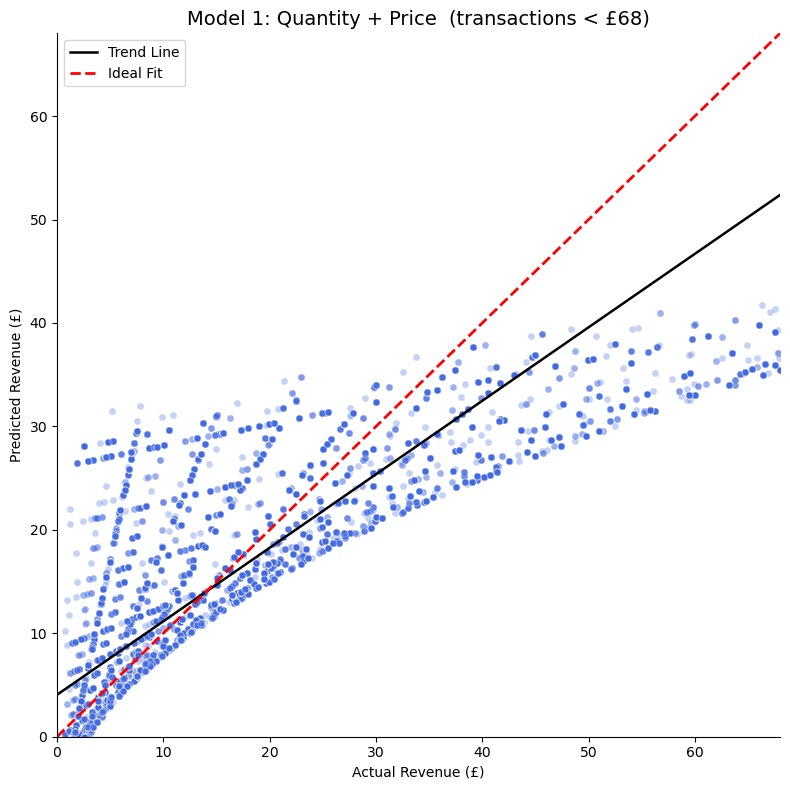

In [81]:
# Model 1 — Actual vs Predicted plot
limit1 = np.percentile(y1_test, 99)
mask1  = (y1_test <= limit1) & (y1_pred <= limit1)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y1_test[mask1], y=y1_pred[mask1], alpha=0.3, color='royalblue', s=25)

# ── Trend Line (added) ──────────────────────────────────────────
m, b = np.polyfit(y1_test[mask1], y1_pred[mask1], 1)
x_line = np.linspace(0, limit1, 200)
plt.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='-', label='Trend Line')
# ───────────────────────────────────────────────────────────────

plt.plot([0, limit1], [0, limit1], color='red', linestyle='--', linewidth=2, label='Ideal Fit')
plt.xlim(0, limit1); plt.ylim(0, limit1)
plt.title(f'Model 1: Quantity + Price  (transactions < £{limit1:.0f})', fontsize=14)
plt.xlabel('Actual Revenue (£)'); plt.ylabel('Predicted Revenue (£)')
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

### Model 2: Quantity + Geography (UK vs International)

In [68]:
# ── Model 2: Quantity + Geography (UK vs International) ────────
df_reg2 = df[(df['quantity'] > 0) & (df['price'] > 0)].copy()
df_reg2['is_uk'] = (df_reg2['country'] == 'United Kingdom').astype(int)

X2 = df_reg2[['quantity', 'is_uk']]
y2 = df_reg2['total_revenue']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=0)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

print("=== Model 2: Quantity + Geography (UK vs International) ===")
print(f"Intercept     : {model2.intercept_:.4f}")
print(f"Coefficients  : {dict(zip(X2.columns, model2.coef_))}")
print(f"R² Score      : {r2_score(y2_test, y2_pred):.4f}")
print(f"MAE           : £{mean_absolute_error(y2_test, y2_pred):.2f}")
print(f"RMSE          : £{np.sqrt(mean_squared_error(y2_test, y2_pred)):.2f}")

=== Model 2: Quantity + Geography (UK vs International) ===
Intercept     : 7.8472
Coefficients  : {'quantity': np.float64(1.0276727728983588), 'is_uk': np.float64(-2.655121230652053)}
R² Score      : 0.2733
MAE           : £6.99
RMSE          : £11.33


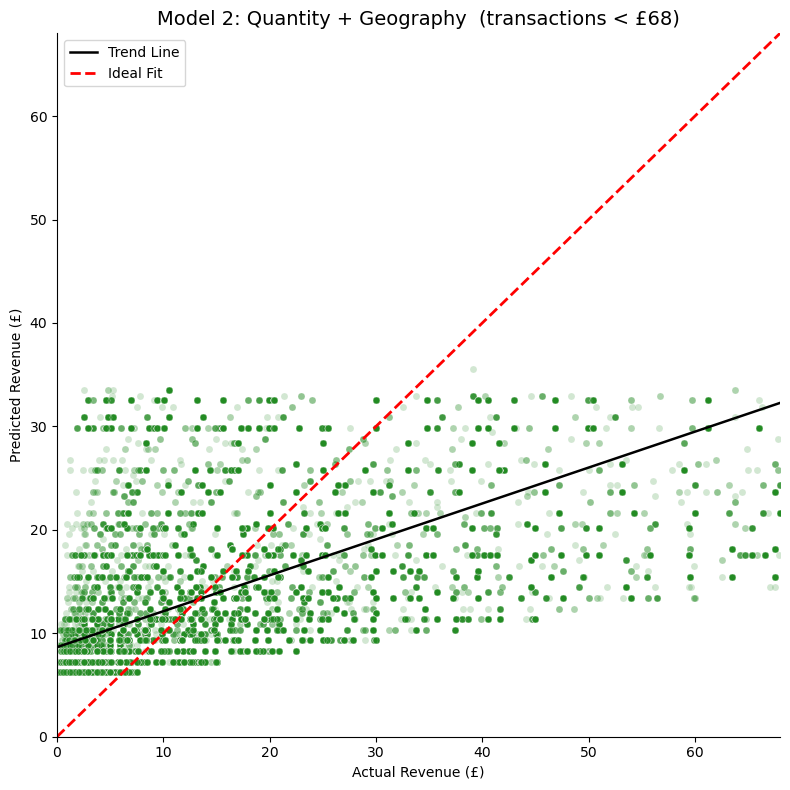

In [80]:
# Model 2 — Actual vs Predicted plot
limit2 = np.percentile(y2_test, 99)
mask2  = (y2_test <= limit2) & (y2_pred <= limit2)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y2_test[mask2], y=y2_pred[mask2], alpha=0.2, color='forestgreen', s=25)

# ── Trend Line (added) ──────────────────────────────────────────
m, b = np.polyfit(y2_test[mask2], y2_pred[mask2], 1)
x_line = np.linspace(0, limit2, 200)
plt.plot(x_line, m * x_line + b, color='black', linewidth=1.8, linestyle='-', label='Trend Line')
# ───────────────────────────────────────────────────────────────

plt.plot([0, limit2], [0, limit2], color='red', linestyle='--', linewidth=2, label='Ideal Fit')
plt.xlim(0, limit2); plt.ylim(0, limit2)
plt.title(f'Model 2: Quantity + Geography  (transactions < £{limit2:.0f})', fontsize=14)
plt.xlabel('Actual Revenue (£)'); plt.ylabel('Predicted Revenue (£)')
plt.legend(); sns.despine(); plt.tight_layout(); plt.show()

# Multiple Linear Regression

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [68]:
x = df[['quantity', 'price', 'purchase_count']]
y = df['total_revenue']

In [69]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=0)

In [70]:
# Call the Model
mlr_model = LinearRegression()

In [71]:
# Train the Model
mlr_model.fit(x_train, y_train)

LinearRegression()

In [72]:
# Model Parameters
print("Intercept:", mlr_model.intercept_)
print("Coefficients:", mlr_model.coef_)

Intercept: -9.233500338620594
Coefficients: [1.46841493e+00 4.97091839e+00 2.40171559e-03]


In [73]:
# Prediction
y_pred = mlr_model.predict(x_test)
y_pred

array([17.5738939 , 15.859809  , 38.6867017 , ..., 10.50888862,
       15.31472737, 15.80697126])

In [74]:
# Model Evaluation
print('MSE: ', round(mean_squared_error(y_test, y_pred), 4))
print('R2: ', round(r2_score(y_test, y_pred), 4))
print('MAE: ', round(mean_absolute_error(y_test, y_pred), 4))
print('MAPE: ', round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('RMSE: ', round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

MSE:  73.2982
R2:  0.5867
MAE:  5.1793
MAPE:  267468322632.8521
RMSE:  8.5614


## 3 Models Comparison

In [75]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [76]:
# Define Features
numeric_features = ['quantity', 'price', 'purchase_count']
categorical_features = ['country_top', 'day_of_week']

target = 'total_revenue'

y = df[target]
X_numeric = df[numeric_features]
X_categorical = df[categorical_features]
X_all = df[numeric_features + categorical_features]

In [77]:
# Train Test Split
Xn_train, Xn_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)
Xc_train, Xc_test, _, _ = train_test_split(X_categorical, y, test_size=0.2, random_state=42)
Xa_train, Xa_test, _, _ = train_test_split(X_all, y, test_size=0.2, random_state=42)

In [82]:
# MODEL 1: Numerical Only
pipeline_numeric = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearRegression())])

pipeline_numeric.fit(Xn_train, y_train)
y_pred_numeric = pipeline_numeric.predict(Xn_test)

In [83]:
# MODEL 2: Categorical Only
preprocessor_cat = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features)])

pipeline_categorical = Pipeline(steps=[
    ("preprocessor", preprocessor_cat),
    ("model", LinearRegression())])

pipeline_categorical.fit(Xc_train, y_train)
y_pred_categorical = pipeline_categorical.predict(Xc_test)

In [84]:
# MODEL 3: Numerical + Categorical
preprocessor_all = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)])

pipeline_all = Pipeline(steps=[
    ("preprocessor", preprocessor_all),
    ("model", LinearRegression())])

pipeline_all.fit(Xa_train, y_train)
y_pred_all = pipeline_all.predict(Xa_test)

In [81]:
# Evaluation Function
def evaluate_model(y_test, y_pred):
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Results Comparison Table
results = pd.DataFrame({
    "Model 1 (Numeric Only)": evaluate_model(y_test, y_pred_numeric),
    "Model 2 (Categorical Only)": evaluate_model(y_test, y_pred_categorical),
    "Model 3 (Numeric + Categorical)": evaluate_model(y_test, y_pred_all)
})

print("Evaluation Metrics Comparison")
print(results)

Evaluation Metrics Comparison
      Model 1 (Numeric Only)  Model 2 (Categorical Only)  \
MAE                 5.169018                    8.487700   
RMSE                8.576678                   13.158907   

      Model 3 (Numeric + Categorical)  
MAE                          5.163148  
RMSE                         8.568396  


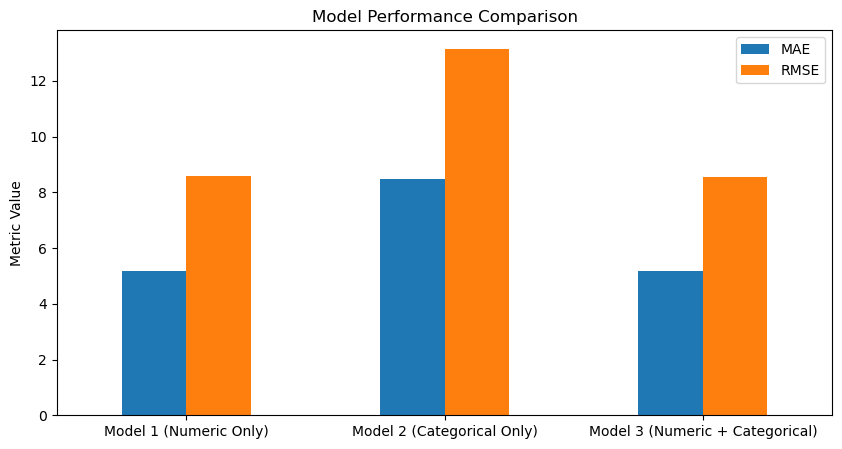

In [85]:
# Graphical Comparison
results.T.plot(kind='bar', figsize=(10, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Metric Value')
plt.xticks(rotation=0)
plt.show()

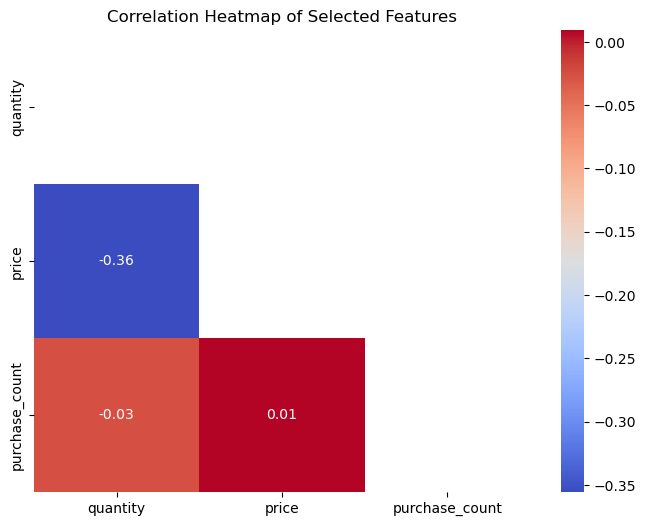

In [86]:
# Correlation Heatmap of Numerical Features
numeric_vars = df[numeric_features]
corr_matrix = numeric_vars.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Selected Features')
plt.show()

## Polynomial Regression

In [87]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

In [88]:
x = df[['quantity', 'price', 'purchase_count']]
y = df['total_revenue']

In [89]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(x)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Model
poly_model = Ridge(alpha=1.0)
poly_model.fit(X_train_scaled, y_train)

Ridge()

In [90]:
y_pred = poly_model.predict(X_test_scaled)
y_pred

array([16.5000053 ,  6.9600717 ,  5.04003393, ..., 17.0000154 ,
        3.89999344,  3.89999314])

In [91]:
print('MSE: ', round(mean_squared_error(y_test, y_pred), 4))
print('R2: ', round(r2_score(y_test, y_pred), 4))
print('MAE: ', round(mean_absolute_error(y_test, y_pred), 4))
print('MAPE: ', round(mean_absolute_percentage_error(y_test, y_pred), 4))
print('RMSE: ', round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))

MSE:  0.0
R2:  1.0
MAE:  0.0
MAPE:  93171429.2351
RMSE:  0.0


# Neural Net

In [92]:
from sklearn.neural_network import MLPRegressor

In [93]:
x = df[['quantity', 'price', 'purchase_count']]
y = df['total_revenue']

In [94]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
model = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)

In [96]:
y_pred = model.predict(X_test_scaled)
y_pred

array([16.50666355,  6.96501048,  5.05634515, ..., 17.00934436,
        3.91288265,  3.91138146])

In [98]:
print(f"MSE:   {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2:    {r2_score(y_test, y_pred):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

MSE:   0.0007
R2:    1.0000
MAE:   0.0160
RMSE:  0.0269


# 6. Customer Segmentation (K-Means and Silhouette Clustering)

In [70]:
# ─────────────────────────────────────────────────────────────
# CUSTOMER SEGMENTATION — K-MEANS CLUSTERING (RFM)
# ─────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [71]:
# ── Step 1: Build RFM Table ─────────────────────────────────
snapshot_date = df['invoicedate'].max()

rfm = df.groupby('customer_id').agg(
    Recency   = ('invoicedate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('invoice',     'nunique'),
    Monetary  = ('total_revenue', 'sum')
).reset_index()

print("RFM Table — first 5 rows:")
print(rfm.head())
print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

RFM Table — first 5 rows:
   customer_id  Recency  Frequency  Monetary
0      12346.0      523         11    372.86
1      12347.0       34          7   3663.19
2      12348.0      243          4    312.36
3      12349.0       13          3   2635.04
4      12350.0      304          1    294.40

RFM Summary Statistics:
       Recency  Frequency   Monetary
count  5658.00    5658.00    5658.00
mean    199.52       5.81    1503.65
std     206.90      11.36    3669.51
min       0.00       1.00       1.25
25%      25.00       1.00     245.59
50%     100.00       3.00     596.45
75%     374.00       6.00    1521.54
max     733.00     360.00  170151.66


In [72]:
# ── Step 2: Scale the RFM Features ─────────────────────────
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

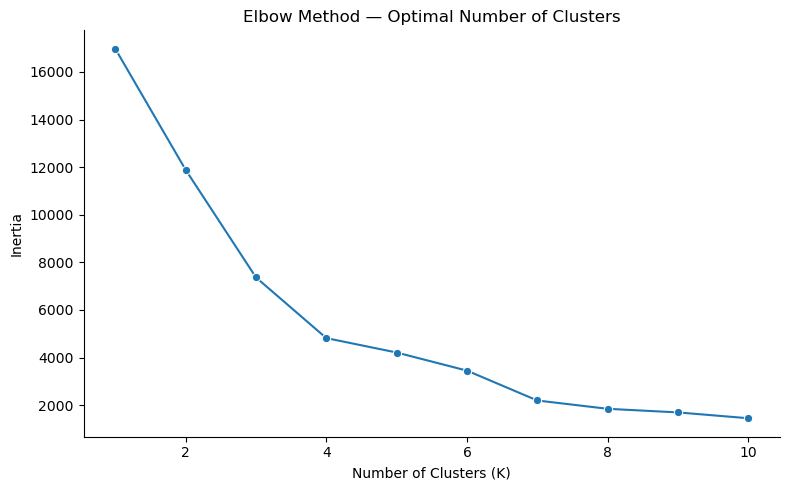

In [73]:
# ── Step 3: Elbow Method — find optimal K ──────────────────
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
sns.lineplot(x=list(k_range), y=inertia, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
sns.despine(); plt.tight_layout(); plt.show()

#### K Means Clustering

In [75]:
# ──  Apply K-Means with K=3 ─────────────────────────
km_final = KMeans(n_clusters=3, random_state=42, n_init='auto')
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

final_sil = silhouette_score(rfm_scaled, rfm['Cluster'])
print(f"Final Silhouette Score (K=3): {final_sil:.4f}")

print("\nCluster Summary (mean RFM values):")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

Final Silhouette Score (K=3): 0.5277

Cluster Summary (mean RFM values):
         Recency  Frequency  Monetary
Cluster                              
0         451.08       2.10    450.43
1          64.04       7.35   1933.33
2          42.44     193.56  58211.55


In [76]:
# ──  Label Clusters ──────────────────────────────────
# Assign business-friendly names based on cluster means
cluster_means = rfm.groupby('Cluster')['Recency'].mean()
sorted_clusters = cluster_means.sort_values().index.tolist()

label_map = {
    sorted_clusters[0]: 'VIP Customers',       # lowest recency = most recent
    sorted_clusters[1]: 'Active Customers',
    sorted_clusters[2]: 'Lost Customers'        # highest recency = haven't bought in a while
}
rfm['Segment'] = rfm['Cluster'].map(label_map)

print("Customer Count per Segment:")
print(rfm['Segment'].value_counts())

Customer Count per Segment:
Segment
Active Customers    3668
Lost Customers      1981
VIP Customers          9
Name: count, dtype: int64


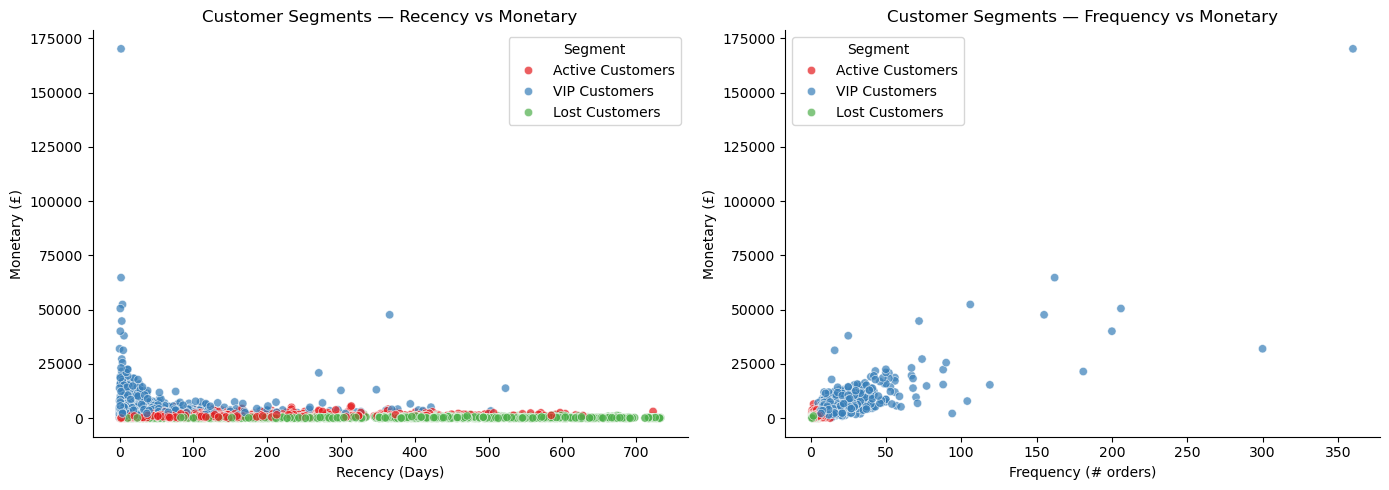

In [92]:
# ──  Visualise Clusters ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recency vs Monetary
sns.scatterplot(ax=axes[0], data=rfm, x='Recency', y='Monetary',
                hue='Segment', palette='Set1', alpha=0.7)
axes[0].set_title('Customer Segments — Recency vs Monetary')
axes[0].set_xlabel('Recency (Days)'); axes[0].set_ylabel('Monetary (£)')

# Frequency vs Monetary
sns.scatterplot(ax=axes[1], data=rfm, x='Frequency', y='Monetary',
                hue='Segment', palette='Set1', alpha=0.7)
axes[1].set_title('Customer Segments — Frequency vs Monetary')
axes[1].set_xlabel('Frequency (# orders)'); axes[1].set_ylabel('Monetary (£)')

sns.despine(); plt.tight_layout(); plt.show()

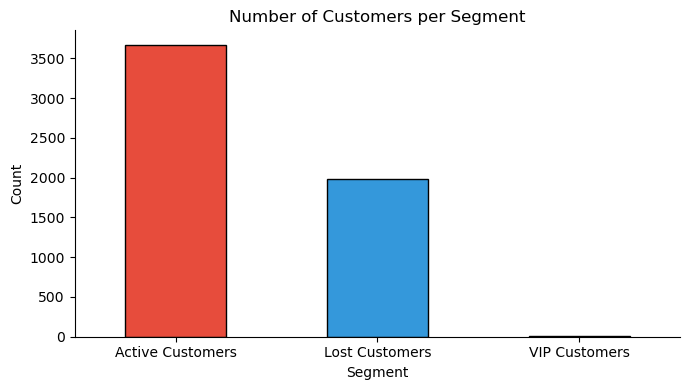

In [78]:
# Segment bar chart
plt.figure(figsize=(7, 4))
rfm['Segment'].value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
plt.title('Number of Customers per Segment')
plt.xlabel('Segment'); plt.ylabel('Count')
plt.xticks(rotation=0); sns.despine(); plt.tight_layout(); plt.show()

#### Silhouette Score

In [99]:
# ──  Final Model — K=2 ───────────────────────────────
km_final       = KMeans(n_clusters=FINAL_K, random_state=42, n_init='auto')
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)
final_sil      = silhouette_score(rfm_scaled, rfm['Cluster'])

print("=" * 50)
print(f" — Final Model: K={FINAL_K}")
print("=" * 50)
print(f"Silhouette Score : {final_sil:.4f}")
print(f"\nCluster Profiles (original scale):")
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))
print(f"\nCluster Sizes:")
print(rfm['Cluster'].value_counts().sort_index())

 — Final Model: K=2
Silhouette Score : 0.4364

Cluster Profiles (original scale):
         Recency  Frequency  Monetary
Cluster                              
0         296.63       2.01    404.90
1          52.21      11.58   3170.36

Cluster Sizes:
Cluster
0    3410
1    2248
Name: count, dtype: int64


STEP 5 — Silhouette Scores
  K=2  Score=0.4364  ← BEST (Selected)
  K=3  Score=0.3468
  K=4  Score=0.3626
  K=5  Score=0.3157
  K=6  Score=0.3121
  K=7  Score=0.2963
  K=8  Score=0.2883


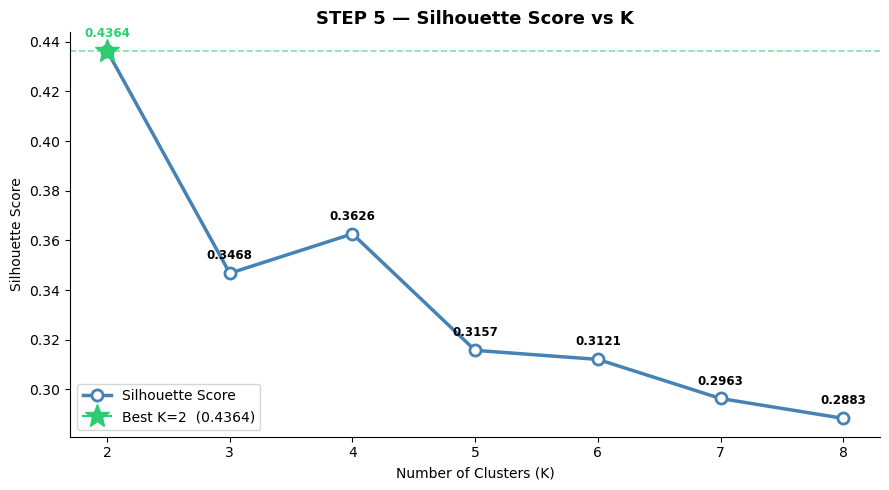

In [103]:
# ──  Label Clusters ───────────────────────────────────
sil_scores = {}

for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init='auto')
    lbl = km.fit_predict(rfm_scaled)
    sil_scores[k] = silhouette_score(rfm_scaled, lbl)

FINAL_K = max(sil_scores, key=sil_scores.get)

print("=" * 50)
print("STEP 5 — Silhouette Scores")
print("=" * 50)
for k, s in sil_scores.items():
    tag = "  ← BEST (Selected)" if k == FINAL_K else ""
    print(f"  K={k}  Score={s:.4f}{tag}")

# ── Line Chart ───────────────────────────────────────────────
plt.figure(figsize=(9, 5))

# Main line
plt.plot(list(sil_scores.keys()), list(sil_scores.values()),
         color='steelblue', linewidth=2.5, marker='o',
         markersize=8, markerfacecolor='white', markeredgewidth=2,
         label='Silhouette Score')

# Highlight best K point
plt.plot(FINAL_K, sil_scores[FINAL_K],
         marker='*', markersize=18, color='#2ecc71',
         zorder=5, label=f'Best K={FINAL_K}  ({sil_scores[FINAL_K]:.4f})')

# Horizontal reference line at best score
plt.axhline(sil_scores[FINAL_K], color='#2ecc71',
            linestyle='--', linewidth=1.2, alpha=0.6)

# Annotate every point
for k, s in sil_scores.items():
    plt.annotate(f'{s:.4f}',
                 xy=(k, s),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=8.5, fontweight='bold',
                 color='#2ecc71' if k == FINAL_K else 'black')

plt.title('STEP 5 — Silhouette Score vs K',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(sil_scores.keys()))
plt.legend(fontsize=10)
sns.despine(); plt.tight_layout(); plt.show()

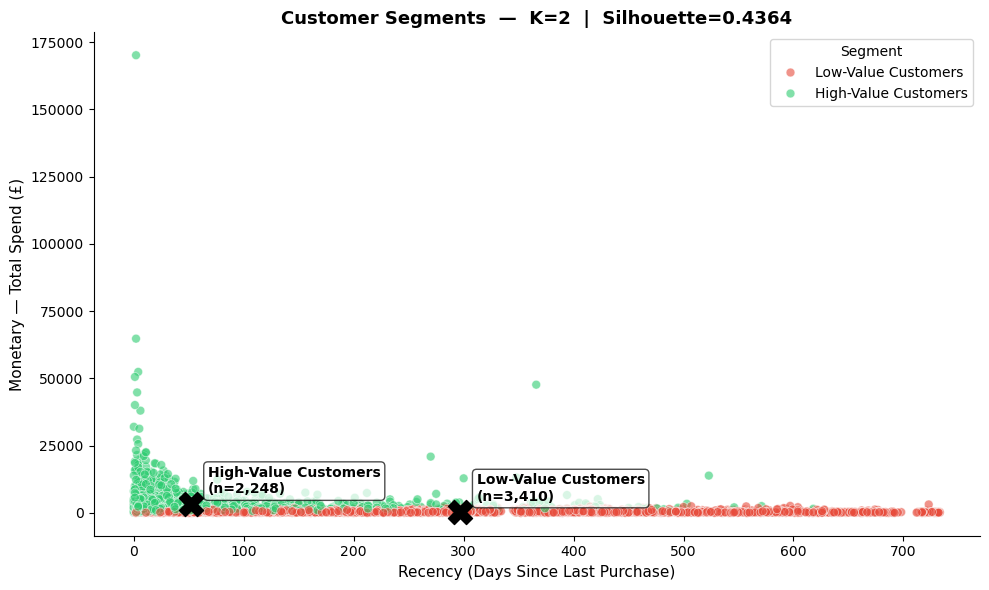

In [105]:

palette = {
    'High-Value Customers' : '#2ecc71',
    'Low-Value Customers'  : '#e74c3c'
}

plt.figure(figsize=(10, 6))

sns.scatterplot(data=rfm, x='Recency', y='Monetary',
                hue='Segment', palette=palette,
                alpha=0.6, s=40)

# Centroid markers + labels
for seg, grp in rfm.groupby('Segment'):
    cx, cy = grp['Recency'].mean(), grp['Monetary'].mean()
    plt.scatter(cx, cy, color='black', marker='X', s=300, zorder=6)
    plt.annotate(f'{seg}\n(n={len(grp):,})',
                 xy=(cx, cy), xytext=(12, 8),
                 textcoords='offset points',
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor='white', edgecolor='black', alpha=0.7))

plt.title(f'Customer Segments  —  K={FINAL_K}  |  Silhouette={final_sil:.4f}',
          fontsize=13, fontweight='bold')
plt.xlabel('Recency (Days Since Last Purchase)', fontsize=11)
plt.ylabel('Monetary — Total Spend (£)', fontsize=11)
plt.legend(title='Segment', fontsize=10, title_fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Final Business Insights

In [99]:
# Overall Average Revenue per Transaction
avg_revenue = df['total_revenue'].mean()
print(f"Overall Average Revenue per Transaction: ${avg_revenue:.2f}")

Overall Average Revenue per Transaction: $13.03


In [100]:
# Total Revenue by Country (Top 10)
df.groupby('country')['total_revenue'].sum().sort_values(ascending=False).head(10)

country
United Kingdom    7382899.66
Germany            251557.48
EIRE               230084.51
France             192886.54
Switzerland         49838.37
Spain               46002.83
Belgium             42747.68
Netherlands         39549.44
Portugal            32269.02
Australia           22715.41
Name: total_revenue, dtype: float64

In [101]:
# Average Revenue by Customer Segment
df.groupby('customer_segment')['total_revenue'].mean().sort_values(ascending=False)

customer_segment
Loyal         13.880998
Regular       12.822355
One-Time      12.159157
Occasional    12.109300
Name: total_revenue, dtype: float64

In [102]:
# Revenue by Price Tier
df.groupby('price_tier')['total_revenue'].mean().sort_values(ascending=False)

price_tier
Premium    23.997016
Mid        15.834427
Budget      9.867818
Luxury           NaN
Name: total_revenue, dtype: float64

In [103]:
# Best Performing Month (by total revenue)
df.groupby('month_name')['total_revenue'].sum().sort_values(ascending=False)

month_name
November     1253650.33
October      1066293.65
September     886478.76
December      706145.02
March         641891.68
May           634152.62
June          609648.29
August        601318.98
July          585612.65
April         552161.58
January       487094.74
February      483226.31
Name: total_revenue, dtype: float64

In [104]:
# Revenue by Quarter
df.groupby('quarter')['total_revenue'].sum()

quarter
1    1612212.73
2    1795962.49
3    2073410.39
4    3026089.00
Name: total_revenue, dtype: float64

In [105]:
# Revenue by Day of Week
df.groupby('day_of_week')['total_revenue'].mean().sort_values(ascending=False)

day_of_week
Saturday     22.368817
Friday       14.163622
Thursday     13.819674
Tuesday      13.813108
Wednesday    13.698152
Monday       13.125369
Sunday        9.783524
Name: total_revenue, dtype: float64

In [106]:
# Average Quantity and Revenue - Loyal vs One-Time Customers
df.groupby('customer_segment')[['quantity', 'total_revenue', 'purchase_count']].mean().T

customer_segment,One-Time,Occasional,Regular,Loyal
quantity,7.289367,7.206187,7.408744,7.503885
total_revenue,12.159157,12.109300,12.822355,13.880998
purchase_count,1.525910,3.966412,9.809772,67.419255


In [107]:
# Summary Table - All Key Metrics
df.groupby('customer_segment')[['quantity', 'price', 'total_revenue', 'purchase_count']].mean().T

customer_segment,One-Time,Occasional,Regular,Loyal
quantity,7.289367,7.206187,7.408744,7.503885
price,2.266202,2.245740,2.258125,2.322386
total_revenue,12.159157,12.109300,12.822355,13.880998
purchase_count,1.525910,3.966412,9.809772,67.419255
